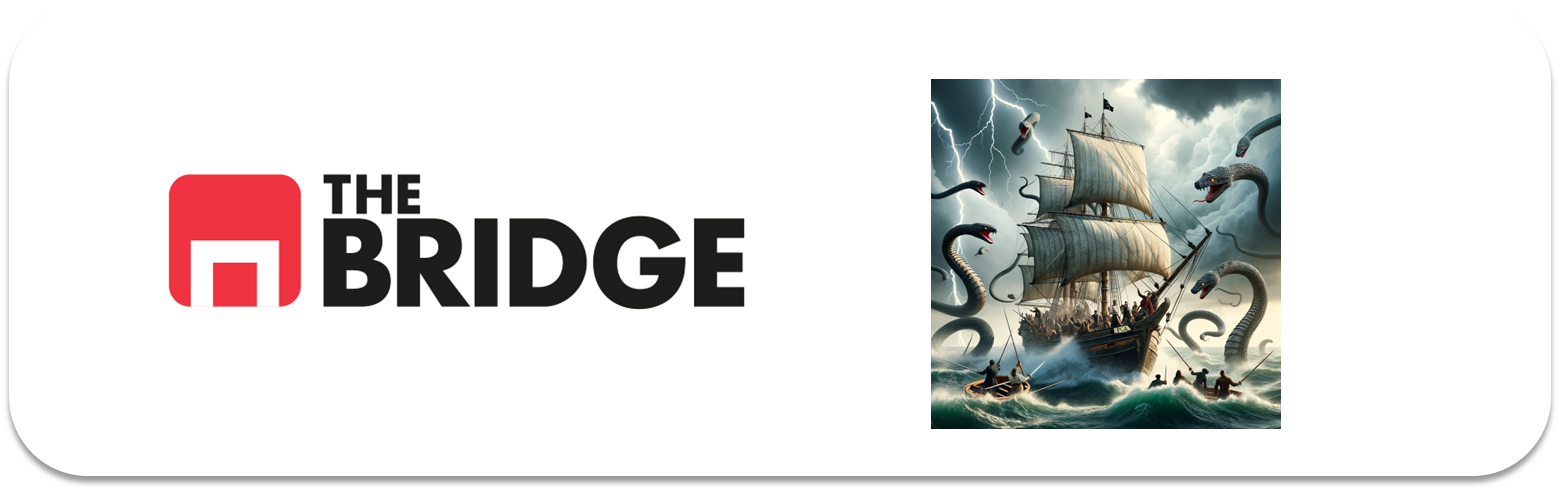

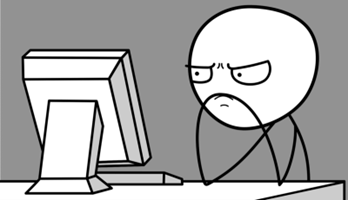

Para ejercitarte y afianzar lo aprendido sobre **PCA**, completa los siguientes ejercicios. Recuerda que necesitarás datos que están en el directorio data que acompaña al notebook (búscalo en el repositorio de ejercicios)

La solución a los mismos las tienes ya, intenta no mirarlos de primeras pero no dejes de hacerlo cuando hayas terminado por si te pudieran aportar.

# Principal Components Analysis: Nutrition
En esta colección de ejercicios no vas a montar ningún modelo de Machine Learning supervisado, sino que vas a practicar con PCA: pretratar el dato antes de calcular sus PCs, interpretarlas, pintar y escoger número de componentes según varianza.


### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [5]:
# Tratamiento de datos
# ==============================================================================
import numpy as np
import pandas as pd
import statsmodels.api as sm

# Gráficos
# ==============================================================================
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager
from matplotlib import style
style.use('ggplot') or plt.style.use('ggplot')

# Preprocesado y modelado
# ==============================================================================
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import scale

# Configuración warnings
# ==============================================================================
import warnings
warnings.filterwarnings('ignore')

### Ejercicio 1: Importa los datos
1. Importa los datos: *nutrition.csv*
2. Observa las columnas que hay, así como su tipo.

In [2]:
df = pd.read_csv("./data/nutrition.csv")
df.head()

,ID,FoodGroup,ShortDescrip,Descrip,CommonName,MfgName,ScientificName,Energy_kcal,Protein_g,Fat_g,...,Folate_USRDA,Niacin_USRDA,Riboflavin_USRDA,Thiamin_USRDA,Calcium_USRDA,Copper_USRDA,Magnesium_USRDA,Phosphorus_USRDA,Selenium_USRDA,Zinc_USRDA
0,1001,Dairy and Egg Products,"BUTTER,WITH SALT","Butter, salted",NaN,NaN,NaN,717.0,0.85,81.11,...,0.0075,0.002625,0.026154,0.004167,0.020000,0.000000,0.004762,0.034286,0.018182,0.008182
1,1002,Dairy and Egg Products,"BUTTER,WHIPPED,WITH SALT","Butter, whipped, with salt",NaN,NaN,NaN,717.0,0.85,81.11,...,0.0075,0.002625,0.026154,0.004167,0.020000,0.000018,0.004762,0.032857,0.018182,0.004545
2,1003,Dairy and Egg Products,"BUTTER OIL,ANHYDROUS","Butter oil, anhydrous",NaN,NaN,NaN,876.0,0.28,99.48,...,0.0000,0.000188,0.003846,0.000833,0.003333,0.000001,0.000000,0.004286,0.000000,0.000909
3,1004,Dairy and Egg Products,"CHEESE,BLUE","Cheese, blue",NaN,NaN,NaN,353.0,21.40,28.74,...,0.0900,0.063500,0.293846,0.024167,0.440000,0.000044,0.054762,0.552857,0.263636,0.241818
4,1005,Dairy and Egg Products,"CHEESE,BRICK","Cheese, brick",NaN,NaN,NaN,371.0,23.24,29.68,...,0.0500,0.007375,0.270000,0.011667,0.561667,0.000027,0.057143,0.644286,0.263636,0.236364


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8618 entries, 0 to 8617
Data columns (total 45 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                8618 non-null   int64  
 1   FoodGroup         8618 non-null   object 
 2   ShortDescrip      8618 non-null   object 
 3   Descrip           8618 non-null   object 
 4   CommonName        1063 non-null   object 
 5   MfgName           1560 non-null   object 
 6   ScientificName    732 non-null    object 
 7   Energy_kcal       8618 non-null   float64
 8   Protein_g         8618 non-null   float64
 9   Fat_g             8618 non-null   float64
 10  Carb_g            8618 non-null   float64
 11  Sugar_g           8618 non-null   float64
 12  Fiber_g           8618 non-null   float64
 13  VitA_mcg          8618 non-null   float64
 14  VitB6_mg          8618 non-null   float64
 15  VitB12_mcg        8618 non-null   float64
 16  VitC_mg           8618 non-null   float64


### Ejercicio 2


Analiza la correlación entre las variables numéricas. 

In [4]:
num_cols = df.select_dtypes(include=np.number).columns
df_num = df[num_cols].copy()

df_num.head()


,ID,Energy_kcal,Protein_g,Fat_g,Carb_g,Sugar_g,Fiber_g,VitA_mcg,VitB6_mg,VitB12_mcg,...,Folate_USRDA,Niacin_USRDA,Riboflavin_USRDA,Thiamin_USRDA,Calcium_USRDA,Copper_USRDA,Magnesium_USRDA,Phosphorus_USRDA,Selenium_USRDA,Zinc_USRDA
0,1001,717.0,0.85,81.11,0.06,0.06,0.0,684.0,0.003,0.17,...,0.0075,0.002625,0.026154,0.004167,0.020000,0.000000,0.004762,0.034286,0.018182,0.008182
1,1002,717.0,0.85,81.11,0.06,0.06,0.0,684.0,0.003,0.13,...,0.0075,0.002625,0.026154,0.004167,0.020000,0.000018,0.004762,0.032857,0.018182,0.004545
2,1003,876.0,0.28,99.48,0.00,0.00,0.0,840.0,0.001,0.01,...,0.0000,0.000188,0.003846,0.000833,0.003333,0.000001,0.000000,0.004286,0.000000,0.000909
3,1004,353.0,21.40,28.74,2.34,0.50,0.0,198.0,0.166,1.22,...,0.0900,0.063500,0.293846,0.024167,0.440000,0.000044,0.054762,0.552857,0.263636,0.241818
4,1005,371.0,23.24,29.68,2.79,0.51,0.0,292.0,0.065,1.26,...,0.0500,0.007375,0.270000,0.011667,0.561667,0.000027,0.057143,0.644286,0.263636,0.236364


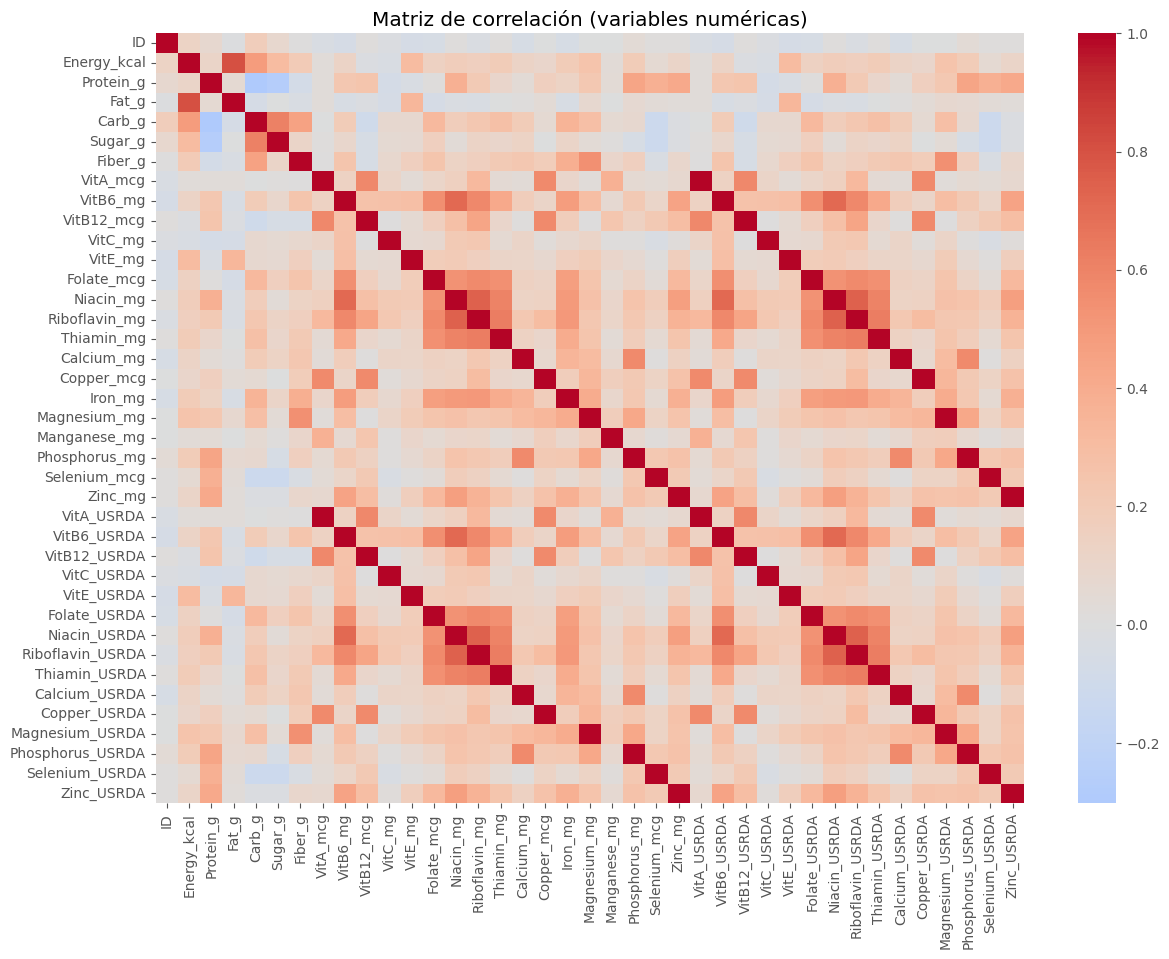

In [6]:
corr = df_num.corr()

plt.figure(figsize=(14,10))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Matriz de correlación (variables numéricas)")
plt.show()


### Ejercicio 3

¿Qué pasa con las columnas USRDA? ¿Hay que tomar alguna decisión?

In [ ]:
usrda_cols = [c for c in df.columns if "USRDA" in c.upper()]
usrda_cols

['VitA_USRDA',
 'VitB6_USRDA',
 'VitB12_USRDA',
 'VitC_USRDA',
 'VitE_USRDA',
 'Folate_USRDA',
 'Niacin_USRDA',
 'Riboflavin_USRDA',
 'Thiamin_USRDA',
 'Calcium_USRDA',
 'Copper_USRDA',
 'Magnesium_USRDA',
 'Phosphorus_USRDA',
 'Selenium_USRDA',
 'Zinc_USRDA']

In [ ]:
len(usrda_cols)

15

In [10]:
df = df.drop(columns=usrda_cols)

### Ejercicio 4: Variables Categóricas

Podríamos analizar las variables no numéricas del dataset e intentar obtener más información, pero por simplicidad en este caso procedemos a eliminarlas. Elimina las variables de texto del dataset.

In [11]:
cat_cols = df.select_dtypes(exclude=np.number).columns.tolist()
cat_cols

['FoodGroup',
 'ShortDescrip',
 'Descrip',
 'CommonName',
 'MfgName',
 'ScientificName']

In [ ]:
df = df.drop(columns=cat_cols)
df.head()

,ID,Energy_kcal,Protein_g,Fat_g,Carb_g,Sugar_g,Fiber_g,VitA_mcg,VitB6_mg,VitB12_mcg,...,Riboflavin_mg,Thiamin_mg,Calcium_mg,Copper_mcg,Iron_mg,Magnesium_mg,Manganese_mg,Phosphorus_mg,Selenium_mcg,Zinc_mg
0,1001,717.0,0.85,81.11,0.06,0.06,0.0,684.0,0.003,0.17,...,0.034,0.005,24.0,0.000,0.02,2.0,0.000,24.0,1.0,0.09
1,1002,717.0,0.85,81.11,0.06,0.06,0.0,684.0,0.003,0.13,...,0.034,0.005,24.0,0.016,0.16,2.0,0.004,23.0,1.0,0.05
2,1003,876.0,0.28,99.48,0.00,0.00,0.0,840.0,0.001,0.01,...,0.005,0.001,4.0,0.001,0.00,0.0,0.000,3.0,0.0,0.01
3,1004,353.0,21.40,28.74,2.34,0.50,0.0,198.0,0.166,1.22,...,0.382,0.029,528.0,0.040,0.31,23.0,0.009,387.0,14.5,2.66
4,1005,371.0,23.24,29.68,2.79,0.51,0.0,292.0,0.065,1.26,...,0.351,0.014,674.0,0.024,0.43,24.0,0.012,451.0,14.5,2.60


### Ejercicio 5: Distribuciones

Analiza la distribución de las variables/columnas/features restantes. Recuerda que PCA es altamente sensible a las escala, así que transforma aquellas variables que creas necesario antes de proceder a escalarlas.


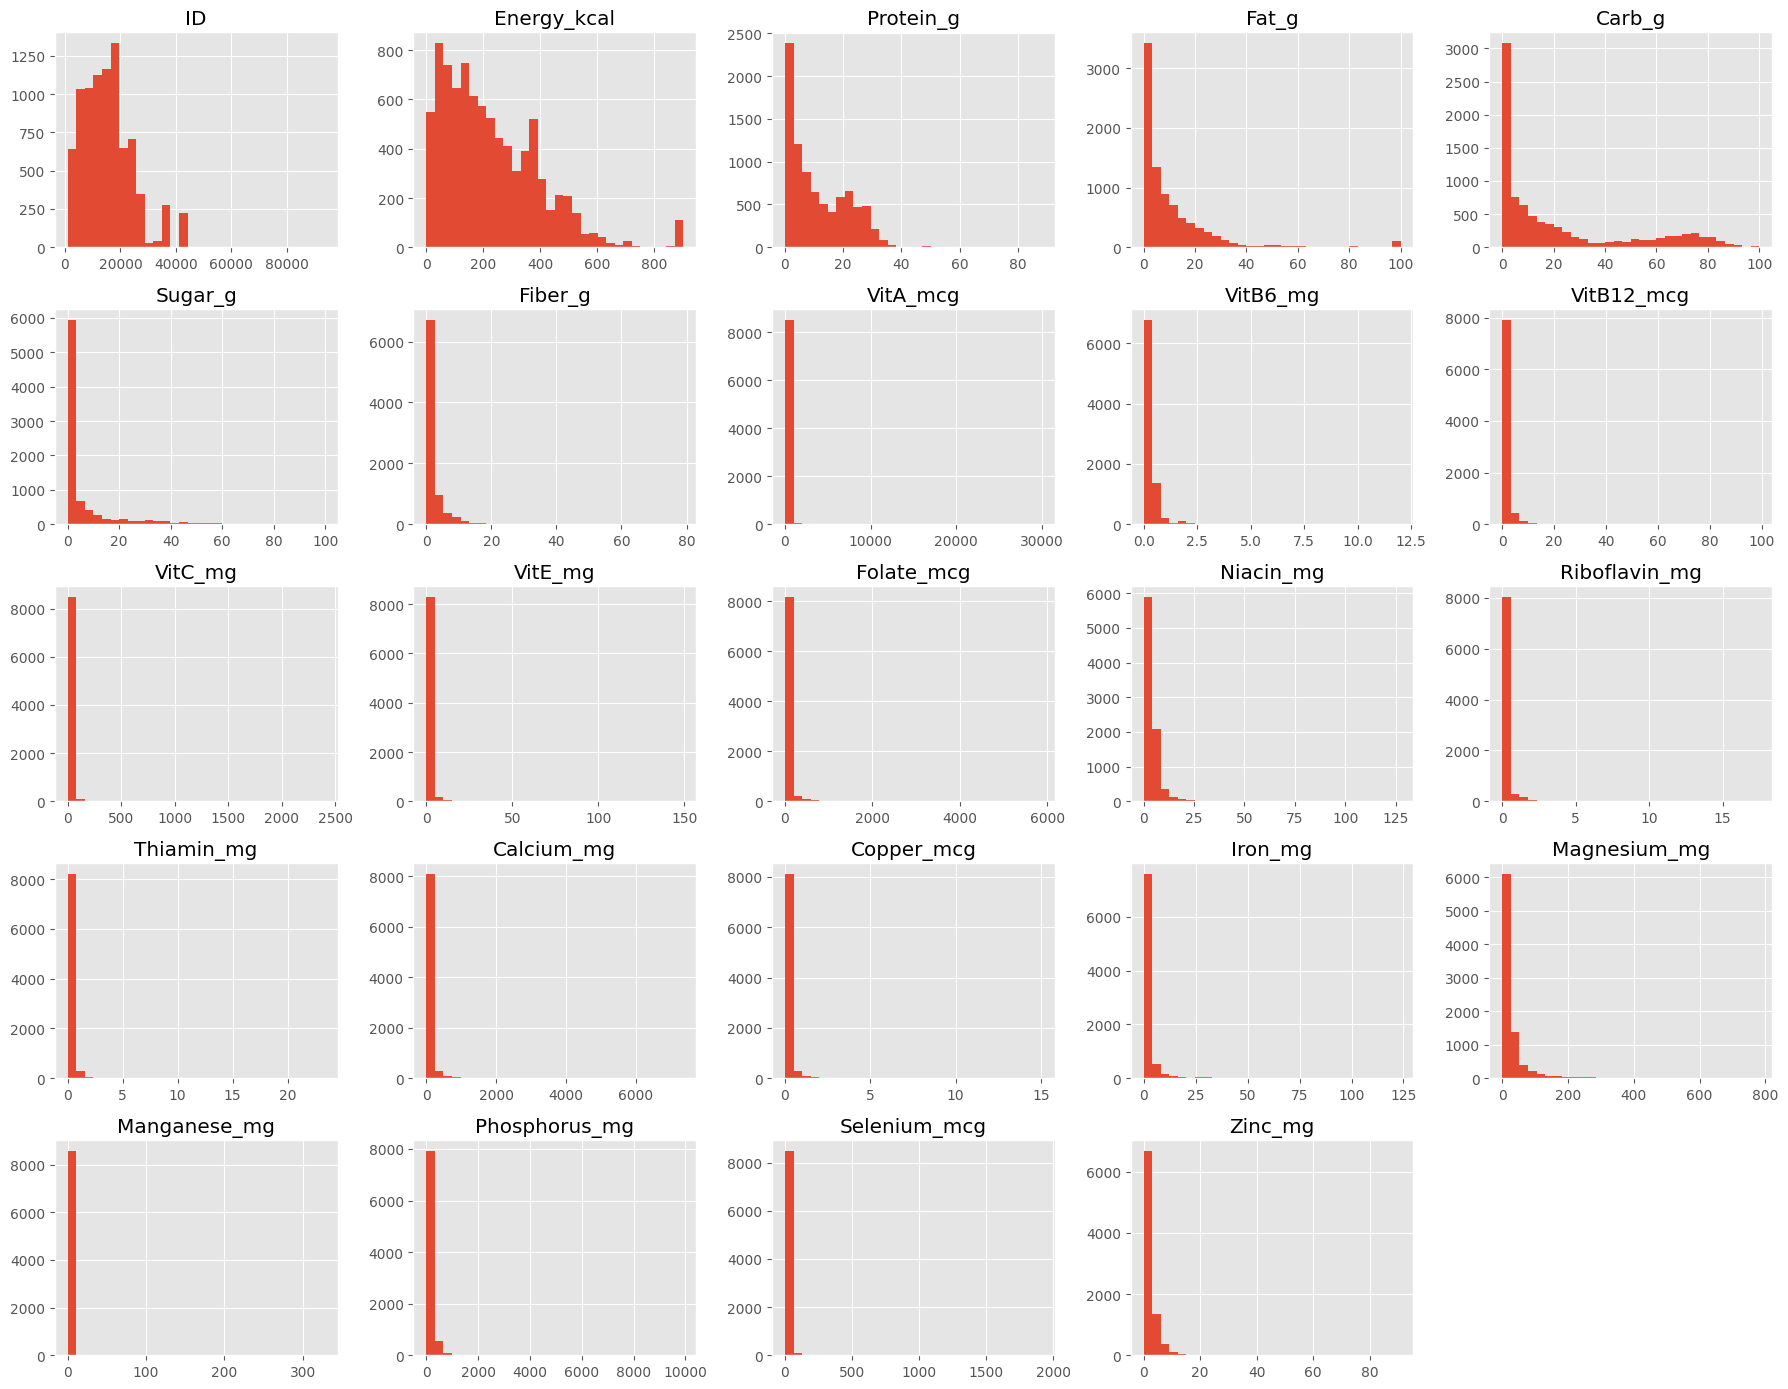

In [ ]:
df.hist(figsize=(18, 14), bins=30)
plt.tight_layout()
plt.show()

In [14]:
skew = df.skew(numeric_only=True).sort_values(ascending=False)
skew.head(15)

Manganese_mg     39.741772
Selenium_mcg     38.207299
VitC_mg          30.907462
VitA_mcg         24.090421
Phosphorus_mg    18.553944
Thiamin_mg       17.510062
Copper_mcg       15.943149
VitE_mg          13.849434
Calcium_mg       13.427978
VitB12_mcg       13.034297
Riboflavin_mg    11.312592
Folate_mcg       10.327038
Zinc_mg           9.629128
VitB6_mg          7.557554
Iron_mg           6.839288
dtype: float64

In [15]:
df_trans = df.copy()

skew_threshold = 2
log_cols = skew[skew > skew_threshold].index.tolist()

log_cols

['Manganese_mg',
 'Selenium_mcg',
 'VitC_mg',
 'VitA_mcg',
 'Phosphorus_mg',
 'Thiamin_mg',
 'Copper_mcg',
 'VitE_mg',
 'Calcium_mg',
 'VitB12_mcg',
 'Riboflavin_mg',
 'Folate_mcg',
 'Zinc_mg',
 'VitB6_mg',
 'Iron_mg',
 'Niacin_mg',
 'Fiber_g',
 'Magnesium_mg',
 'Fat_g',
 'Sugar_g']

In [16]:
for col in log_cols:
    # log1p solo si la columna no tiene valores negativos
    if (df_trans[col] >= 0).all():
        df_trans[col] = np.log1p(df_trans[col])


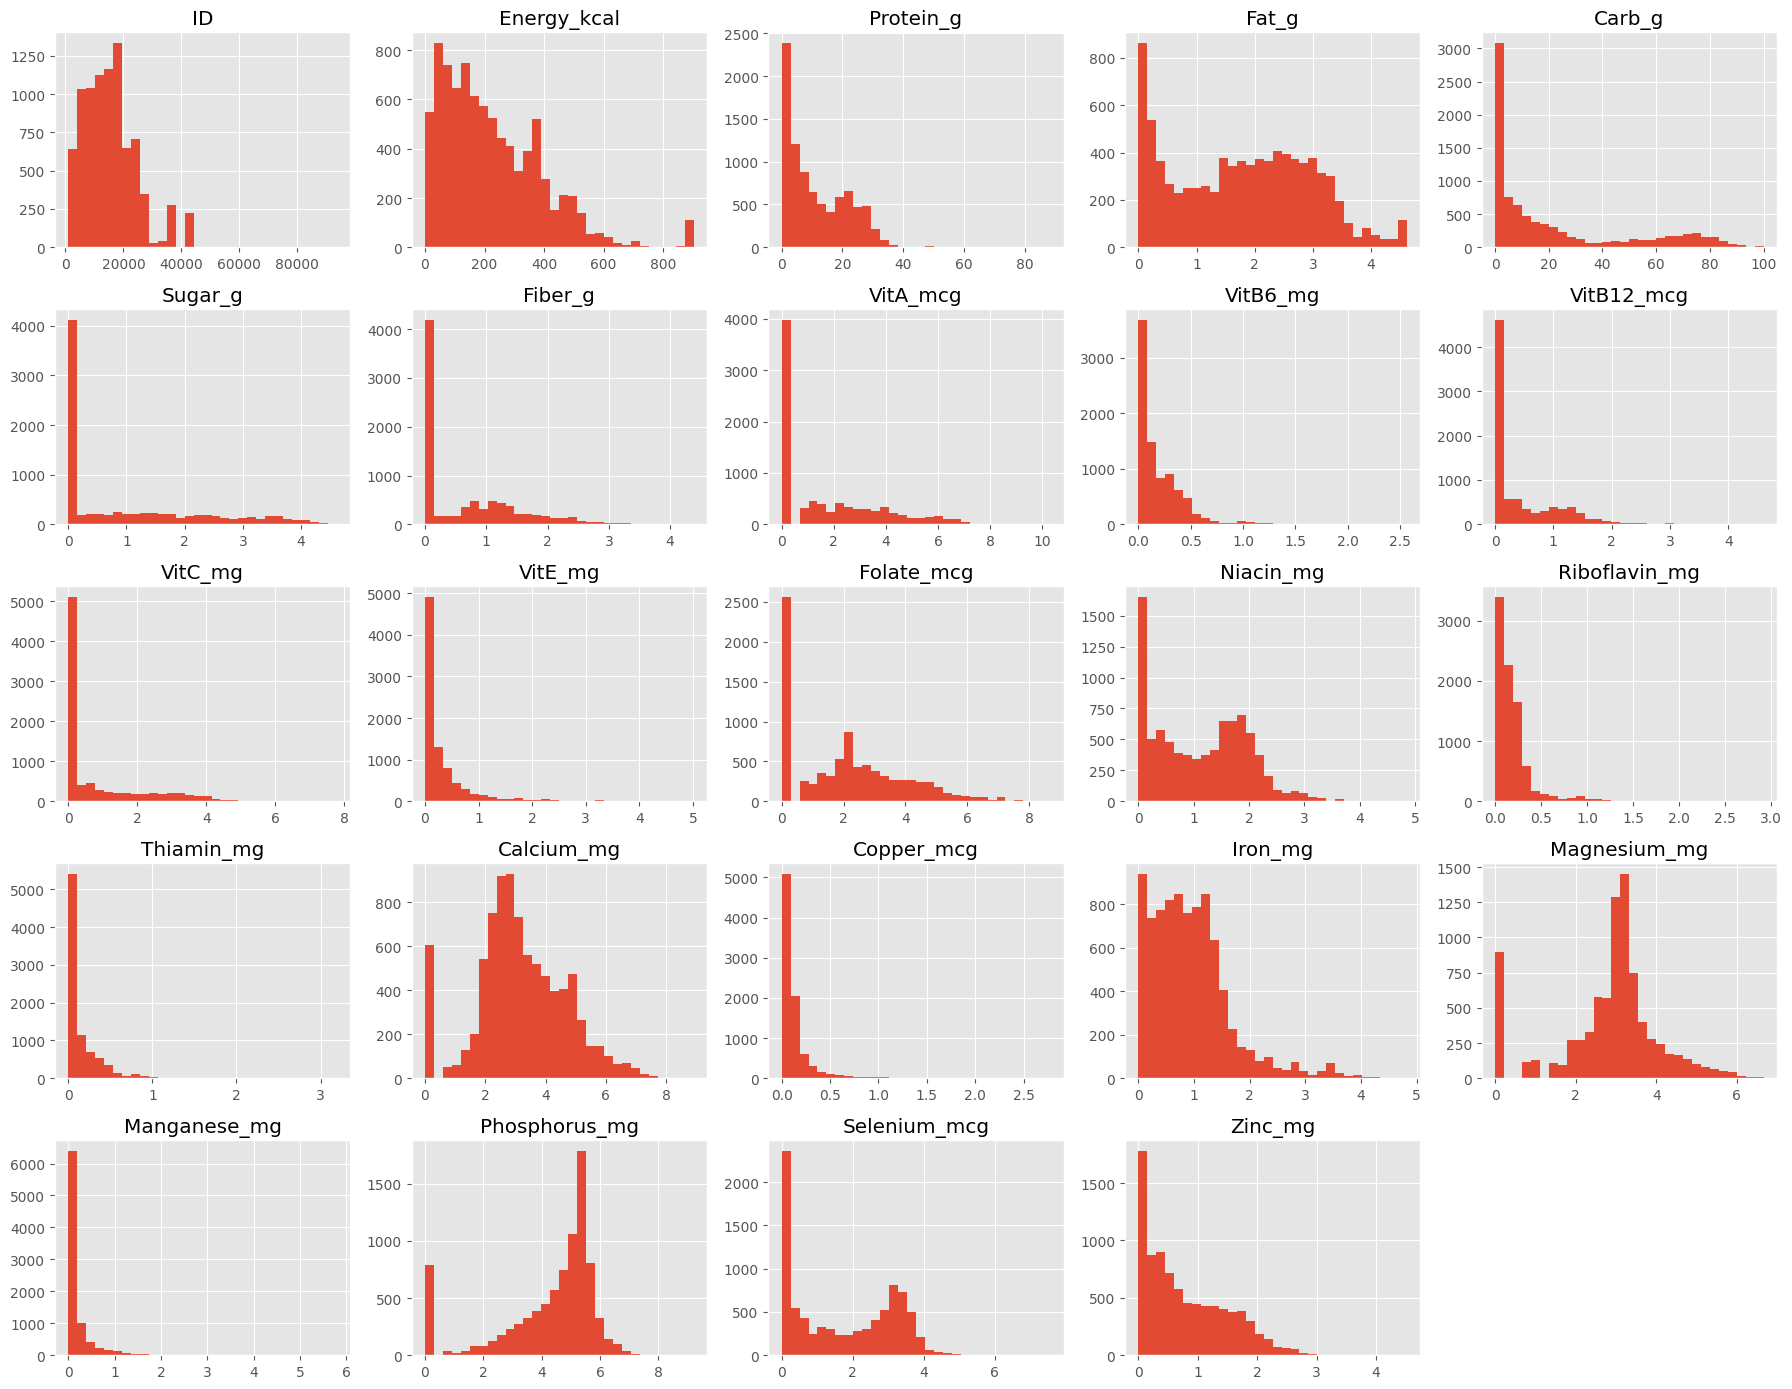

In [17]:
df_trans.hist(figsize=(18, 14), bins=30)
plt.tight_layout()
plt.show()


### Ejercicio 6: Estandarizado
Estandariza cada variable. (No es necesario que dividas en train y test por simplificar).

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_trans)

X_scaled.shape

(8618, 24)

### Ejercicio 7: Implementación del PCA
Prueba a montar un PCA con todos los componentes. Para ello utiliza los datos previamente transformados y escalados.

In [19]:
from sklearn.decomposition import PCA

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

X_pca.shape

(8618, 24)

### Ejercicio 8

Muestra en un dataframe la relación de cada componente con cada feature. En general, este paso no lo haremos salvo que sea necesario a posteriori explicar la influencia de alguna componente en función de las features originales, pero ahora, muéstralas.

In [20]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=df_trans.columns,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)]
)

loadings.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC15,PC16,PC17,PC18,PC19,PC20,PC21,PC22,PC23,PC24
ID,0.019824,-0.008156,0.253412,0.063934,-0.265806,0.460380,0.737474,-0.089441,-0.187708,0.131666,...,-0.062556,0.014496,-0.090080,0.056206,0.025891,-0.002384,0.073664,-0.036927,0.023556,0.036355
Energy_kcal,0.133155,0.109261,0.526789,0.024250,0.248445,-0.079530,-0.105956,0.058470,-0.072933,-0.039816,...,-0.134486,0.002275,-0.036313,-0.177083,0.072549,-0.206249,-0.065370,0.006001,0.103461,0.633856
Protein_g,0.225640,-0.323744,0.037737,0.103007,-0.064839,-0.020136,0.003207,0.046660,0.156997,0.072584,...,0.136669,0.481003,-0.052368,-0.054341,0.543597,-0.318961,-0.322873,0.029252,0.036708,-0.163484
Fat_g,0.139753,-0.119979,0.461090,0.067479,0.347762,0.032579,-0.119377,0.093196,-0.023402,0.164076,...,-0.134870,0.021808,0.069462,0.264904,0.005190,0.295439,0.110881,-0.110336,-0.001759,-0.528917
Carb_g,0.095173,0.384746,0.241335,-0.089677,-0.182668,0.141857,-0.088495,0.018551,-0.023180,-0.271726,...,-0.006498,-0.028755,-0.026780,-0.429786,-0.180660,-0.303508,-0.128788,0.223727,-0.170641,-0.456653


In [21]:
loadings["PC1"].abs().sort_values(ascending=False).head(15)

Niacin_mg        0.305465
Zinc_mg          0.299176
Phosphorus_mg    0.293782
Iron_mg          0.291916
Magnesium_mg     0.283032
Riboflavin_mg    0.277745
VitB6_mg         0.272522
Selenium_mcg     0.241644
Thiamin_mg       0.241276
Protein_g        0.225640
VitB12_mcg       0.212381
Folate_mcg       0.207930
Copper_mcg       0.198823
Calcium_mg       0.159523
Manganese_mg     0.151850
Name: PC1, dtype: float64

In [23]:
loadings["PC2"].abs().sort_values(ascending=False).head(15)

Fiber_g         0.391428
Carb_g          0.384746
Sugar_g         0.342280
Protein_g       0.323744
VitB12_mcg      0.260268
Selenium_mcg    0.252703
Manganese_mg    0.243506
VitC_mg         0.234733
Zinc_mg         0.186604
Folate_mcg      0.181461
Calcium_mg      0.172894
Thiamin_mg      0.157358
VitE_mg         0.132492
Niacin_mg       0.120958
Fat_g           0.119979
Name: PC2, dtype: float64

### Ejercicio 9: Aportación de cada PCA
Visualiza en un diagrama de líneas la suma acumulada de la varianza explicativa del PCA.

Si tuviéses que quedarte con 70-75 % de la varianza original, ¿con cuántos Principal Components te quedarías?

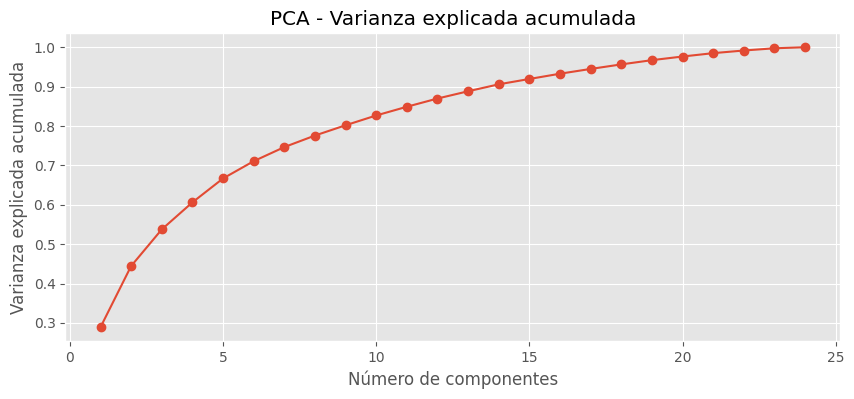

In [24]:
explained = pca.explained_variance_ratio_
cum_explained = np.cumsum(explained)

plt.figure(figsize=(10,4))
plt.plot(range(1, len(cum_explained)+1), cum_explained, marker="o")
plt.xlabel("Número de componentes")
plt.ylabel("Varianza explicada acumulada")
plt.title("PCA - Varianza explicada acumulada")
plt.grid(True)
plt.show()


In [25]:
n_70 = np.argmax(cum_explained >= 0.70) + 1
n_75 = np.argmax(cum_explained >= 0.75) + 1

print("PCs para 70%:", n_70)
print("PCs para 75%:", n_75)


PCs para 70%: 6
PCs para 75%: 8


### Ejercicio 10: Reducción de features

Crea un nuevo PCA con X Principal Components, siendo X la cantidad de PC escogidos en el apartado anterior.

Obtén el nuevo dataset con el mismo número de registros que el original, pero en este caso con X features, que representan los PC elegidos.

In [26]:
n_components = n_75
pca_reduced = PCA(n_components=n_components)

X_pca_reduced = pca_reduced.fit_transform(X_scaled)

df_pca = pd.DataFrame(
    X_pca_reduced,
    columns=[f"PC{i+1}" for i in range(n_components)]
)

df_pca.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
0,-2.085536,-0.158136,1.930593,0.180222,4.765241,-0.228548,-1.254590,0.479923
1,-2.050026,-0.100661,1.938391,0.195098,4.737895,-0.272194,-1.238180,0.544422
2,-3.062313,-0.130537,3.061586,-0.538544,5.117491,-1.219279,-0.838069,0.747087
3,1.270316,-1.417958,-0.671235,0.811826,2.610371,1.417642,-2.064369,0.851689
4,1.000855,-1.396031,-0.595030,1.098906,2.820847,1.670079,-2.095395,1.192360


In [27]:
df_pca.shape

(8618, 8)